#Part 1 (10 points):
This step involves downloading, preparing, and visualizing your
dataset. Create a convolutional base using a common pattern: a stack of Conv and
MaxPooling layers. Depending on the problem and the dataset you must decide what
pattern you want to use (i.e., how many Conv layers and how many pooling layers).
Please describe why you chose a particular pattern. Add the final dense layer(s).
Compile and train the model. Report the final evaluation and describe the metrics.


In [ ]:
# using the oxford flowers dataset:
# https://www.robots.ox.ac.uk/%7Evgg/data/flowers/102/
# https://www.tensorflow.org/datasets/catalog/oxford_flowers102

import tensorflow as tf
import tensorflow_datasets as tfds

(train_ds, val_ds, test_ds), metadata = tfds.load(
    'oxford_flowers102',
    split=['train', 'validation', 'test'],
    with_info=True,
    as_supervised=True,
)

In [ ]:
# a method to format and normalize the images
def format_image(image, label):
    image = tf.image.resize(image, (224, 224)) / 255.0
    return image, label

In [ ]:
# prepare the batches
BATCH_SIZE = 32
train_ds = train_ds.map(format_image).shuffle(1000).batch(BATCH_SIZE).prefetch(1)
val_ds = val_ds.map(format_image).batch(BATCH_SIZE).prefetch(1)

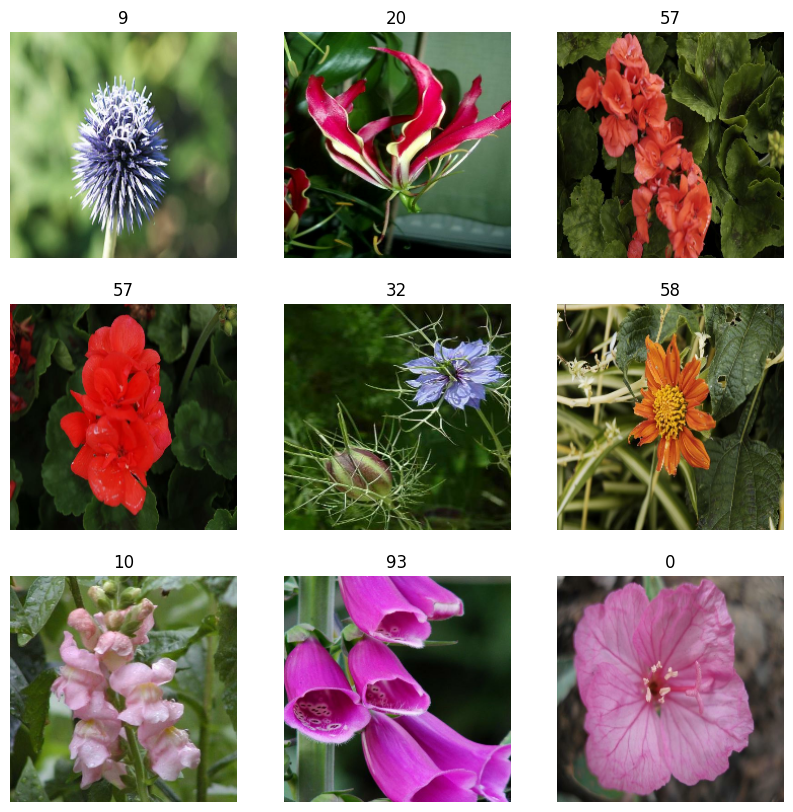

In [ ]:
# a quick look at the data to ensure it is what we expect

import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(int(labels[i]))
        plt.axis("off")

    plt.show()

In [ ]:
# creating a convoutional architecture
from tensorflow.keras import layers, models

IMG_SHAPE = (224, 224, 3)

model = models.Sequential([
    # 1st layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=IMG_SHAPE),
    layers.MaxPooling2D((2, 2)),

    # 2nd layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3rd layer
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # flatten for dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # output layer
    layers.Dense(102, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


I utilized the described common pattern of convolutional and pooling layers. I choose 3 different filter sizes. The first was to find lower level features with the smaller size of 32. Then, by incrasing the filters on the later layers, I ensured that more complex structures would be identified. Maxpooling is neccessary for every layer in order to keep the number of dimensions in check. As this is a dataset that has features that wildly vary in complexity, the varying filter sizes were required.

In [ ]:
# compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 102)            │        13,158 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,182,118 (42.66 MB)

 Trainable params: 11,182,118 (42.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# training
EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 171s 5s/step - accuracy: 0.0098 - loss: 4.6893 - val_accuracy: 0.0167 - val_loss: 4.6113
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 169s 5s/step - accuracy: 0.0147 - loss: 4.5488 - val_accuracy: 0.0441 - val_loss: 4.4252
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 189s 6s/step - accuracy: 0.0637 - loss: 4.1773 - val_accuracy: 0.0549 - val_loss: 4.1088
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 178s 6s/step - accuracy: 0.2500 - loss: 3.0805 - val_accuracy: 0.1020 - val_loss: 4.1144
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 201s 6s/step - accuracy: 0.6216 - loss: 1.4619 - val_accuracy: 0.1098 - val_loss: 5.1542
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 147s 5s/step - accuracy: 0.8931 - loss: 0.4411 - val_accuracy: 0.1176 - val_loss: 6.8006
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 151s 5s/step - accuracy: 0.9667 - loss: 0.1248 - val_accuracy: 0.1167 - val_loss: 7.4734
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 157s 5s/step - accuracy: 0.9922 - loss: 0.0546 - val_accuracy: 0.1216 - v

In [ ]:
# prep test set
test_ds = test_ds.map(format_image).batch(BATCH_SIZE).prefetch(1)

In [ ]:
# accuracy on the test set
test_loss, test_acc = model.evaluate(test_ds)
print('Test accuracy:', test_acc)

193/193 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.1094 - loss: 9.2142
Test accuracy: 0.10944869369268417


In [ ]:
# find the true labels and model predictions
import numpy as np
y_true = []
y_pred = []


for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
# calculate the other metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('Precision:', precision)
print('Recall:', recall)
print('F1 score:', f1)

Precision: 0.13253589235770352
Recall: 0.11827519184902656
F1 score: 0.10866898428344558


For metrics, I went with the basic ones: accuracy, precision, recall, and F1 score. These are pretty standard and when used as a whole can give a strong idea of the model's performance.

#Part 2 (10 points):
The following models are widely used for transfer learning because of
their performance and architectural innovations:
1. VGG (e.g., VGG16 or VGG19).
2. GoogLeNet (e.g., InceptionV3).
3. Residual Network (e.g., ResNet50).
4. MobileNet (e.g., MobileNetV2)

Choose any one of the above models to perform the classification task you did in Part 1.
Evaluate the results using the same metrics as in Part 1. Are there any differences? Why
or why not? Describe in detail.


In [ ]:
# import MobileNet for transfer learning
from tensorflow.keras.applications import MobileNetV2

# load the model in
base_model = MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# make sure it cannot train on its own
base_model.trainable = False

# create a new head
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(102, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# compile
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 102)            │        26,214 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,612,134 (9.96 MB)

 Trainable params: 354,150 (1.35 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# train the transfer model
transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.0892 - loss: 4.3933 - val_accuracy: 0.2814 - val_loss: 3.5977
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.3902 - loss: 2.8154 - val_accuracy: 0.5147 - val_loss: 2.2902
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.6422 - loss: 1.6178 - val_accuracy: 0.6559 - val_loss: 1.6186
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7735 - loss: 1.0149 - val_accuracy: 0.6902 - val_loss: 1.3430
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8627 - loss: 0.6773 - val_accuracy: 0.7206 - val_loss: 1.1875
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9118 - loss: 0.4752 - val_accuracy: 0.7510 - val_loss: 1.0746
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9333 - loss: 0.3502 - val_accuracy: 0.7441 - val_loss: 0.9952
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9569 - loss: 0.2684 - val_accuracy: 0.7696 - val_loss

In [ ]:
# evaluation

# accuracy on the test set
test_loss, test_acc = transfer_model.evaluate(test_ds)
print('Test accuracy:', test_acc)

# find the true labels and model predictions
import numpy as np
y_true = []
y_pred = []


for images, labels in test_ds:
    preds = transfer_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# calculate the other metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('Precision:', precision)
print('Recall:', recall)
print('F1 score:', f1)

193/193 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.7557 - loss: 0.9571
Test accuracy: 0.7557326555252075
Precision: 0.7401863085220434
Recall: 0.7744724919847188
F1 score: 0.7469727795046578


This was an astounding jump in accuracy, recall, precision, and f1 score. Each jumped more than 60%!! The big difference here is of course going to be the model. My little CNN had to learn everything from scratch off only a few thousand images. Meanwhile, MobileNetV2 was been trained on a gargantuan ImageNet database. This allowed for the MobileNet to transfer the features it had developed on the massive database, and map them to the flowers. This is why the accuracy was so high versus the custom made model.

#Part 3 (10 points):
Use data augmentation to increase the diversity of your dataset by
applying random transformations such as image rotation (you can use any other
technique as well). Repeat the process from part 1 with this augmented data. Did you
observe any difference in results? Why or why not?


In [ ]:
# creating a custom CNN with augmentation baked in

augmentation_model = models.Sequential([
    layers.Input(shape=IMG_SHAPE),

    # data augmentation
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),

    # 1st layer
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 2nd layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3rd layer
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # flatten for dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # output layer
    layers.Dense(102, activation='softmax')
])

In [ ]:
# compile
augmentation_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

augmentation_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 102)            │        13,158 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,182,118 (42.66 MB)

 Trainable params: 11,182,118 (42.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train the aug model
augmentation_history = augmentation_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 173s 5s/step - accuracy: 0.0059 - loss: 4.6627 - val_accuracy: 0.0029 - val_loss: 4.6127
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 159s 5s/step - accuracy: 0.0137 - loss: 4.5321 - val_accuracy: 0.0275 - val_loss: 4.4255
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 169s 5s/step - accuracy: 0.0284 - loss: 4.3021 - val_accuracy: 0.0422 - val_loss: 4.1519
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 151s 5s/step - accuracy: 0.0608 - loss: 3.9969 - val_accuracy: 0.0637 - val_loss: 3.9595
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 150s 5s/step - accuracy: 0.0912 - loss: 3.7882 - val_accuracy: 0.1157 - val_loss: 3.7396
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 151s 5s/step - accuracy: 0.1422 - loss: 3.5504 - val_accuracy: 0.1265 - val_loss: 3.6704
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 160s 5s/step - accuracy: 0.1529 - loss: 3.3865 - val_accuracy: 0.1667 - val_loss: 3.5333
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 166s 5s/step - accuracy: 0.1873 - loss: 3.2232 - val_accuracy: 0.1765 - v

In [ ]:
# evaluation

# accuracy on the test set
test_loss, test_acc = augmentation_model.evaluate(test_ds)
print('Test accuracy:', test_acc)

# find the true labels and model predictions
import numpy as np
y_true = []
y_pred = []


for images, labels in test_ds:
    preds = augmentation_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# calculate the other metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('Precision:', precision)
print('Recall:', recall)
print('F1 score:', f1)

193/193 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.1675 - loss: 3.6008
Test accuracy: 0.16750691831111908
Precision: 0.16804318685416803
Recall: 0.18740090631225093
F1 score: 0.14327560865660835


There is definetely a noticable increase from the results seen in part 1, but they are no where near as impressive as the gains from part 2. These increases are ~5% versus the 60%+ seen by using transfer learning. These results are expected. We knew there would be a small increase by peturbing the training set in order to regularize the weights a bit more, but you will not see those huge gains without dramaitically increasing the size of the training set.